# Joint Intent + NER — Evaluation Dashboard

Loads the fine-tuned LoRA adapter, runs inference on the 35 test examples (5 per class), and displays a **colorful comparison dashboard** of predictions vs ground truth for both intent classification and NER.

In [1]:
"""Environment setup — run this cell first."""
import os
from pathlib import Path

# ── Corporate SSL bypass (must precede any network-touching import) ──
os.environ["HF_HUB_DISABLE_SSL_VERIFICATION"] = "1"
os.environ["HF_HUB_DISABLE_SSL_VERIFY"] = "1"
os.environ["CURL_CA_BUNDLE"] = ""
os.environ["REQUESTS_CA_BUNDLE"] = ""

import ssl, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
ssl._create_default_https_context = ssl._create_unverified_context

import requests
_orig = requests.Session.request
def _patch(self, *a, **kw):
    kw["verify"] = False
    return _orig(self, *a, **kw)
requests.Session.request = _patch

from dotenv import load_dotenv

import json, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

def _repo_root():
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "finetune_data_gen" / "generate_from_prompts.py").is_file():
            return base
    raise FileNotFoundError("Could not locate repo root")

REPO_ROOT = _repo_root()
FINETUNE_ROOT = REPO_ROOT / "finetune_data_gen"

for env_path in [FINETUNE_ROOT / ".env", REPO_ROOT / ".env"]:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f"Loaded env from {env_path}")
        break

if str(FINETUNE_ROOT) not in sys.path:
    sys.path.insert(0, str(FINETUNE_ROOT))

print(f"Repo root: {REPO_ROOT}")
print(f"SSL bypass: active")

Loaded env from /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/.env
Repo root: /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml
SSL bypass: active


### Optional: Refresh AWS credentials from `~/Downloads/credentials`

Run this cell after downloading fresh AWS SSO / STS credentials. It writes them into `finetune_data_gen/.env`, then **re-run Cell 1** to pick them up.

**Skip this cell** if your `.env` credentials are still valid.

In [2]:
"""Optional: write finetune_data_gen/.env from ~/Downloads/credentials"""
import os
from pathlib import Path


def _repo_and_finetune():
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        marker = base / "finetune_data_gen" / "generate_from_prompts.py"
        if marker.is_file():
            return base, base / "finetune_data_gen"
    raise FileNotFoundError("Could not find finetune_data_gen/ (walk up from cwd).")


_, FINETUNE_ROOT = _repo_and_finetune()
CREDENTIALS_FILE = Path.home() / "Downloads" / "credentials"
ENV_FILE = FINETUNE_ROOT / ".env"

if not CREDENTIALS_FILE.exists():
    raise FileNotFoundError(
        f"Credentials file not found: {CREDENTIALS_FILE}\n"
        "Download/copy your credentials to ~/Downloads/credentials first."
    )

KEY_MAP = {
    "aws_access_key_id": "AWS_ACCESS_KEY_ID",
    "aws_secret_access_key": "AWS_SECRET_ACCESS_KEY",
    "aws_session_token": "AWS_SESSION_TOKEN",
}

parsed = {}
with open(CREDENTIALS_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("[") or line.startswith("#"):
            continue
        if "=" in line:
            key, _, value = line.partition("=")
            key = key.strip().lower()
            value = value.strip()
            if key in KEY_MAP:
                parsed[key] = value

missing = [k for k in KEY_MAP if k not in parsed]
if missing:
    raise KeyError(
        f"Missing key(s) in {CREDENTIALS_FILE}: {missing}\n"
        f"Found keys: {list(parsed.keys())}"
    )

region = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")
with open(CREDENTIALS_FILE, "r") as _cf:
    for _line in _cf:
        _line = _line.strip()
        if _line.startswith("[") or _line.startswith("#") or "=" not in _line:
            continue
        _k, _, _v = _line.partition("=")
        if _k.strip().lower() in ("region", "aws_default_region", "aws_region"):
            region = _v.strip()
            break

env_lines = [f"{KEY_MAP[k]}={parsed[k]}" for k in KEY_MAP]
env_lines.append(f"AWS_DEFAULT_REGION={region}")
ENV_FILE.write_text("\n".join(env_lines) + "\n", encoding="utf-8")

readback = {}
for line in ENV_FILE.read_text().splitlines():
    line = line.strip()
    if line and "=" in line and not line.startswith("#"):
        k, _, v = line.partition("=")
        readback[k.strip()] = v.strip()

for ini_key, env_key in KEY_MAP.items():
    if parsed[ini_key] != readback.get(env_key, ""):
        raise RuntimeError("Verification failed — .env content does not match credentials file!")

print(f"✅ .env updated from {CREDENTIALS_FILE}")
print(f"   Written to: {ENV_FILE}")
print(f"   Access Key ID : {parsed['aws_access_key_id'][:8]}...")
print(f"   Token length  : {len(parsed['aws_session_token'])} chars")
print()
print("⚠️  Now re-run Cell 1 (env setup) to reload the updated credentials.")

✅ .env updated from /Users/soumendu_bhattacharjee/Downloads/credentials
   Written to: /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/.env
   Access Key ID : ASIA6GBM...
   Token length  : 488 chars

⚠️  Now re-run Cell 1 (env setup) to reload the updated credentials.


## 1. Load Model + LoRA Adapter

In [3]:
from transformers import AutoTokenizer
from peft import PeftModel
from joint_intent_ner_classifier import (
    JointIntentNERModel, INTENT_LABELS, NER_LABELS,
    INTENT_ID2LABEL, INTENT_LABEL2ID, NER_ID2LABEL, NER_LABEL2ID,
    MODEL_CHECKPOINT, MAX_SEQ_LEN, align_labels_with_tokens,
)

ADAPTER_DIR = str(FINETUNE_ROOT / "output" / "distilbert-lora-joint-7class" / "lora-adapter")
TEST_DATA_PATH = FINETUNE_ROOT / "output" / "distilbert-lora-joint-7class" / "test_data.json"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

base_model = JointIntentNERModel.from_pretrained(
    MODEL_CHECKPOINT,
    num_intents=len(INTENT_LABELS),
    num_ner_labels=len(NER_LABELS),
)
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()

print(f"Model loaded from {ADAPTER_DIR}")
print(f"Test data from {TEST_DATA_PATH}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

JointIntentNERModel LOAD REPORT from: /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/models/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
ner_head.weight         | MISSING    | 
intent_head.weight      | MISSING    | 
intent_head.bias        | MISSING    | 
ner_head.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded from /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/output/distilbert-lora-joint-7class/lora-adapter
Test data from /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/output/distilbert-lora-joint-7class/test_data.json


Model loaded from /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/output/distilbert-lora-joint-7class/lora-adapter
Test data from /Users/soumendu_bhattacharjee/Documents/DATA_SCIENCE/app-titan-ai-ml/finetune_data_gen/output/distilbert-lora-joint-7class/test_data.json


## 2. Load Test Data

In [4]:
test_data = json.loads(TEST_DATA_PATH.read_text(encoding="utf-8"))
test_df = pd.DataFrame(test_data)
print(f"Test examples: {len(test_df)}")
print(f"Per class: {test_df['label'].value_counts().sort_index().to_dict()}")

Test examples: 35
Per class: {'analytical_field': 5, 'analytical_field_map': 5, 'analytical_reservoir': 5, 'field_summary_dashboard': 5, 'map_update': 5, 'out_of_scope': 5, 'reservoir_summary_dashboard': 5}


## 3. Run Inference

In [5]:
def predict_single(text, tokens, ner_tags):
    """Run inference on a single example. Returns predicted intent and NER tags."""
    enc, aligned_ner = align_labels_with_tokens(tokenizer, tokens, ner_tags, MAX_SEQ_LEN)

    input_ids = torch.tensor([enc["input_ids"]], dtype=torch.long)
    attention_mask = torch.tensor([enc["attention_mask"]], dtype=torch.long)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    intent_logits = outputs["intent_logits"]
    ner_logits = outputs["ner_logits"]

    pred_intent_id = intent_logits.argmax(-1).item()
    pred_intent = INTENT_ID2LABEL[pred_intent_id]

    ner_pred_ids = ner_logits.argmax(-1)[0].tolist()

    word_ids = enc.word_ids()
    pred_word_tags = []
    seen_words = set()
    for idx, wid in enumerate(word_ids):
        if wid is not None and wid not in seen_words:
            seen_words.add(wid)
            pred_word_tags.append(NER_ID2LABEL.get(ner_pred_ids[idx], "O"))

    # Pad or truncate to match token length
    while len(pred_word_tags) < len(tokens):
        pred_word_tags.append("O")
    pred_word_tags = pred_word_tags[:len(tokens)]

    return pred_intent, pred_word_tags


from tqdm.notebook import tqdm

results = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Running inference"):
    pred_intent, pred_ner = predict_single(row["text"], row["tokens"], row["ner_tags"])
    results.append({
        "text": row["text"],
        "tokens": row["tokens"],
        "true_intent": row["label"],
        "pred_intent": pred_intent,
        "intent_match": row["label"] == pred_intent,
        "true_ner": row["ner_tags"],
        "pred_ner": pred_ner,
        "ner_match": row["ner_tags"] == pred_ner,
    })

res_df = pd.DataFrame(results)
print(f"\nInference complete: {len(res_df)} examples")
print(f"Intent accuracy: {res_df['intent_match'].mean():.2%}")
print(f"NER exact match: {res_df['ner_match'].mean():.2%}")

Running inference:   0%|          | 0/35 [00:00<?, ?it/s]


Inference complete: 35 examples
Intent accuracy: 100.00%
NER exact match: 60.00%


## 4. Intent Classification Dashboard

In [6]:
INTENT_COLORS = {
    "field_summary_dashboard":    "#48bb78",
    "reservoir_summary_dashboard": "#4299e1",
    "analytical_field":           "#ed8936",
    "analytical_reservoir":       "#9f7aea",
    "analytical_field_map":       "#f56565",
    "map_update":                 "#38b2ac",
    "out_of_scope":              "#a0aec0",
}

def intent_badge(label, is_correct=True):
    color = INTENT_COLORS.get(label, "#718096")
    border = "3px solid #2d3748" if is_correct else "3px solid #e53e3e"
    icon = "&#10004;" if is_correct else "&#10008;"
    return f'<span style="background:{color}; color:white; padding:3px 10px; border-radius:12px; font-size:12px; font-weight:bold; border:{border};">{icon} {label}</span>'

html_rows = []
for _, r in res_df.iterrows():
    match = r["intent_match"]
    row_bg = "#f0fff4" if match else "#fff5f5"
    html_rows.append(f"""
    <tr style="background:{row_bg};">
        <td style="padding:8px 12px; max-width:350px; word-wrap:break-word; font-size:13px;">{r['text']}</td>
        <td style="padding:8px 12px;">{intent_badge(r['true_intent'])}</td>
        <td style="padding:8px 12px;">{intent_badge(r['pred_intent'], match)}</td>
        <td style="padding:8px 12px; text-align:center; font-size:18px;">{'<span style="color:#38a169;">&#10004;</span>' if match else '<span style="color:#e53e3e; font-weight:bold;">&#10008;</span>'}</td>
    </tr>""")

intent_html = f"""
<h3 style="font-family:system-ui; color:#2d3748;">Intent Classification: Predicted vs Ground Truth</h3>
<table style="border-collapse:collapse; width:100%; font-family:system-ui;">
<thead>
    <tr style="background:#2c5282; color:white;">
        <th style="padding:10px 12px; text-align:left;">User Utterance</th>
        <th style="padding:10px 12px; text-align:left;">True Intent</th>
        <th style="padding:10px 12px; text-align:left;">Predicted Intent</th>
        <th style="padding:10px 12px; text-align:center;">Match</th>
    </tr>
</thead>
<tbody>{''.join(html_rows)}</tbody>
</table>
"""
display(HTML(intent_html))

User Utterance,True Intent,Predicted Intent,Match
analyze Burgan and Safaniya field production,✔ analytical_field,✔ analytical_field,✔
compare Ghawar and Zakum field performance,✔ analytical_field,✔ analytical_field,✔
compare Oman and UAE fields by production,✔ analytical_field,✔ analytical_field,✔
compare Rumaila and Kirkuk field reserves,✔ analytical_field,✔ analytical_field,✔
compare oil and gas fields in Saudi Arabia,✔ analytical_field,✔ analytical_field,✔
get active fields in Shaybah,✔ analytical_field_map,✔ analytical_field_map,✔
list onshore fields in Bu Hasa,✔ analytical_field_map,✔ analytical_field_map,✔
show producing fields in Zakum,✔ analytical_field_map,✔ analytical_field_map,✔
show producing fields in Marmul,✔ analytical_field_map,✔ analytical_field_map,✔
show offshore gas fields in Gulf of Suez,✔ analytical_field_map,✔ analytical_field_map,✔


## 5. Intent Accuracy by Class

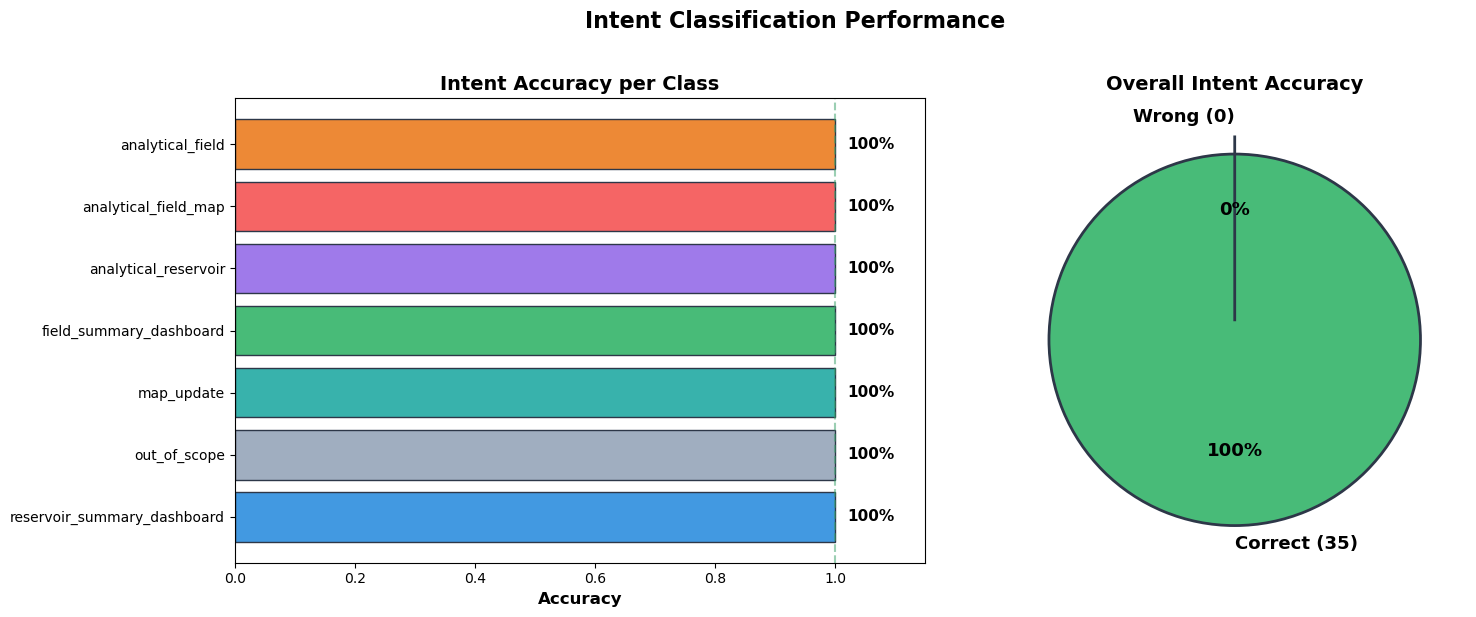

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Per-class accuracy
classes = sorted(res_df["true_intent"].unique())
accs = []
colors = []
for cls in classes:
    mask = res_df["true_intent"] == cls
    acc = res_df.loc[mask, "intent_match"].mean()
    accs.append(acc)
    colors.append(INTENT_COLORS.get(cls, "#718096"))

bars = axes[0].barh(classes, accs, color=colors, edgecolor="#2d3748", linewidth=1)
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel("Accuracy", fontsize=12, fontweight="bold")
axes[0].set_title("Intent Accuracy per Class", fontsize=14, fontweight="bold")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{acc:.0%}", va="center", fontsize=11, fontweight="bold")
axes[0].axvline(x=1.0, color="#38a169", linestyle="--", alpha=0.5)
axes[0].invert_yaxis()

# Overall pie
n_correct = res_df["intent_match"].sum()
n_wrong = len(res_df) - n_correct
wedges, texts, autotexts = axes[1].pie(
    [n_correct, n_wrong],
    labels=[f"Correct ({n_correct})", f"Wrong ({n_wrong})"],
    colors=["#48bb78", "#fc8181"],
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 13, "fontweight": "bold"},
    wedgeprops={"edgecolor": "#2d3748", "linewidth": 2},
    explode=[0.05, 0.05],
)
axes[1].set_title("Overall Intent Accuracy", fontsize=14, fontweight="bold")

fig.suptitle("Intent Classification Performance", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6. NER Entity Extraction Dashboard

In [8]:
NER_COLORS = {
    "FIELD_NAME":     "#48bb78",
    "FIELD_ID":       "#38a169",
    "RESERVOIR_NAME": "#4299e1",
    "RESERVOIR_ID":   "#3182ce",
    "MAP_LAYER":      "#ed8936",
    "COUNTRY":        "#9f7aea",
    "BASIN":          "#d69e2e",
    "HC_TYPE":        "#e53e3e",
    "FIELD_STATUS":   "#dd6b20",
    "LOCATION_TYPE":  "#d53f8c",
}

def render_tagged_text(tokens, tags, label_prefix=""):
    """Render tokens with colored NER entity highlights."""
    html_parts = []
    i = 0
    while i < len(tokens):
        tag = tags[i] if i < len(tags) else "O"
        if tag.startswith("B-"):
            entity_type = tag[2:]
            color = NER_COLORS.get(entity_type, "#718096")
            entity_tokens = [tokens[i]]
            j = i + 1
            while j < len(tokens) and j < len(tags) and tags[j] == f"I-{entity_type}":
                entity_tokens.append(tokens[j])
                j += 1
            entity_text = " ".join(entity_tokens)
            html_parts.append(
                f'<span style="background:{color}; color:white; padding:2px 6px; '
                f'border-radius:4px; font-size:12px; font-weight:bold; margin:1px;">'
                f'{entity_text} <sub style="font-size:9px; opacity:0.8;">{entity_type}</sub></span>'
            )
            i = j
        else:
            html_parts.append(f'<span style="font-size:13px;">{tokens[i]}</span>')
            i += 1
    return " ".join(html_parts)


ner_rows = []
for _, r in res_df.iterrows():
    tokens = r["tokens"]
    true_ner_html = render_tagged_text(tokens, r["true_ner"])
    pred_ner_html = render_tagged_text(tokens, r["pred_ner"])
    match = r["ner_match"]
    row_bg = "#f0fff4" if match else "#fffaf0"

    ner_rows.append(f"""
    <tr style="background:{row_bg}; border-bottom:1px solid #e2e8f0;">
        <td style="padding:10px; font-size:12px; color:#4a5568; max-width:120px;">{intent_badge(r['true_intent'])}</td>
        <td style="padding:10px; line-height:2;">{true_ner_html}</td>
        <td style="padding:10px; line-height:2;">{pred_ner_html}</td>
        <td style="padding:10px; text-align:center; font-size:18px;">{'<span style="color:#38a169;">&#10004;</span>' if match else '<span style="color:#e53e3e;">&#10008;</span>'}</td>
    </tr>""")

ner_html = f"""
<h3 style="font-family:system-ui; color:#2d3748;">NER Entity Extraction: Predicted vs Ground Truth</h3>
<p style="font-family:system-ui; color:#718096; font-size:13px;">Colored spans show extracted entities. Compare true (left) vs predicted (right).</p>
<table style="border-collapse:collapse; width:100%; font-family:system-ui;">
<thead>
    <tr style="background:#2c5282; color:white;">
        <th style="padding:10px 12px; text-align:left; width:140px;">Intent</th>
        <th style="padding:10px 12px; text-align:left;">Ground Truth NER</th>
        <th style="padding:10px 12px; text-align:left;">Predicted NER</th>
        <th style="padding:10px 12px; text-align:center; width:60px;">Match</th>
    </tr>
</thead>
<tbody>{''.join(ner_rows)}</tbody>
</table>
"""
display(HTML(ner_html))

Intent,Ground Truth NER,Predicted NER,Match
✔ analytical_field,analyze Burgan FIELD_NAME and Safaniya FIELD_NAME field production,analyze Burgan FIELD_NAME and Safaniya FIELD_NAME field production,✔
✔ analytical_field,compare Ghawar FIELD_NAME and Zakum FIELD_NAME field performance,compare Ghawar FIELD_NAME and Zakum FIELD_NAME field performance,✔
✔ analytical_field,compare Oman COUNTRY and UAE COUNTRY fields by production,compare Oman COUNTRY and UAE COUNTRY fields by production,✔
✔ analytical_field,compare Rumaila FIELD_NAME and Kirkuk FIELD_NAME field reserves,compare Rumaila FIELD_NAME and Kirkuk FIELD_NAME field reserves,✔
✔ analytical_field,compare oil HC_TYPE and gas HC_TYPE fields in Saudi Arabia COUNTRY,compare oil HC_TYPE and gas HC_TYPE fields in Saudi COUNTRY Arabia COUNTRY,✘
✔ analytical_field_map,get active FIELD_STATUS fields in Shaybah FIELD_NAME,get active FIELD_STATUS fields in Shaybah FIELD_NAME,✔
✔ analytical_field_map,list onshore LOCATION_TYPE fields in Bu Hasa FIELD_NAME,list onshore fields in Bu Hasa FIELD_NAME,✘
✔ analytical_field_map,show producing FIELD_STATUS fields in Zakum FIELD_NAME,show producing fields in Zakum FIELD_NAME,✘
✔ analytical_field_map,show producing FIELD_STATUS fields in Marmul FIELD_NAME,show producing fields in Marmul FIELD_NAME,✘
✔ analytical_field_map,show offshore LOCATION_TYPE gas HC_TYPE fields in Gulf of Suez BASIN,show offshore gas HC_TYPE fields in Gulf of Suez COUNTRY,✘


## 7. NER Performance by Entity Type

In [9]:
from collections import Counter

def extract_entities_from_bio(tokens, tags):
    """Extract (entity_type, entity_text) tuples from BIO tags."""
    entities = []
    i = 0
    while i < len(tokens) and i < len(tags):
        if tags[i].startswith("B-"):
            etype = tags[i][2:]
            parts = [tokens[i]]
            j = i + 1
            while j < len(tokens) and j < len(tags) and tags[j] == f"I-{etype}":
                parts.append(tokens[j])
                j += 1
            entities.append((etype, " ".join(parts)))
            i = j
        else:
            i += 1
    return entities


true_entities_all = Counter()
pred_entities_all = Counter()
correct_entities = Counter()

for _, r in res_df.iterrows():
    true_ents = set(extract_entities_from_bio(r["tokens"], r["true_ner"]))
    pred_ents = set(extract_entities_from_bio(r["tokens"], r["pred_ner"]))
    for etype, _ in true_ents:
        true_entities_all[etype] += 1
    for etype, _ in pred_ents:
        pred_entities_all[etype] += 1
    for ent in true_ents & pred_ents:
        correct_entities[ent[0]] += 1

all_types = sorted(set(true_entities_all.keys()) | set(pred_entities_all.keys()))

ner_perf = []
for etype in all_types:
    tp = correct_entities[etype]
    total_true = true_entities_all[etype]
    total_pred = pred_entities_all[etype]
    prec = tp / total_pred if total_pred > 0 else 0
    rec = tp / total_true if total_true > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    ner_perf.append({"Entity": etype, "True": total_true, "Predicted": total_pred,
                     "Correct": tp, "Precision": prec, "Recall": rec, "F1": f1})

perf_df = pd.DataFrame(ner_perf)
print("NER Performance by Entity Type:")
print()

NER Performance by Entity Type:



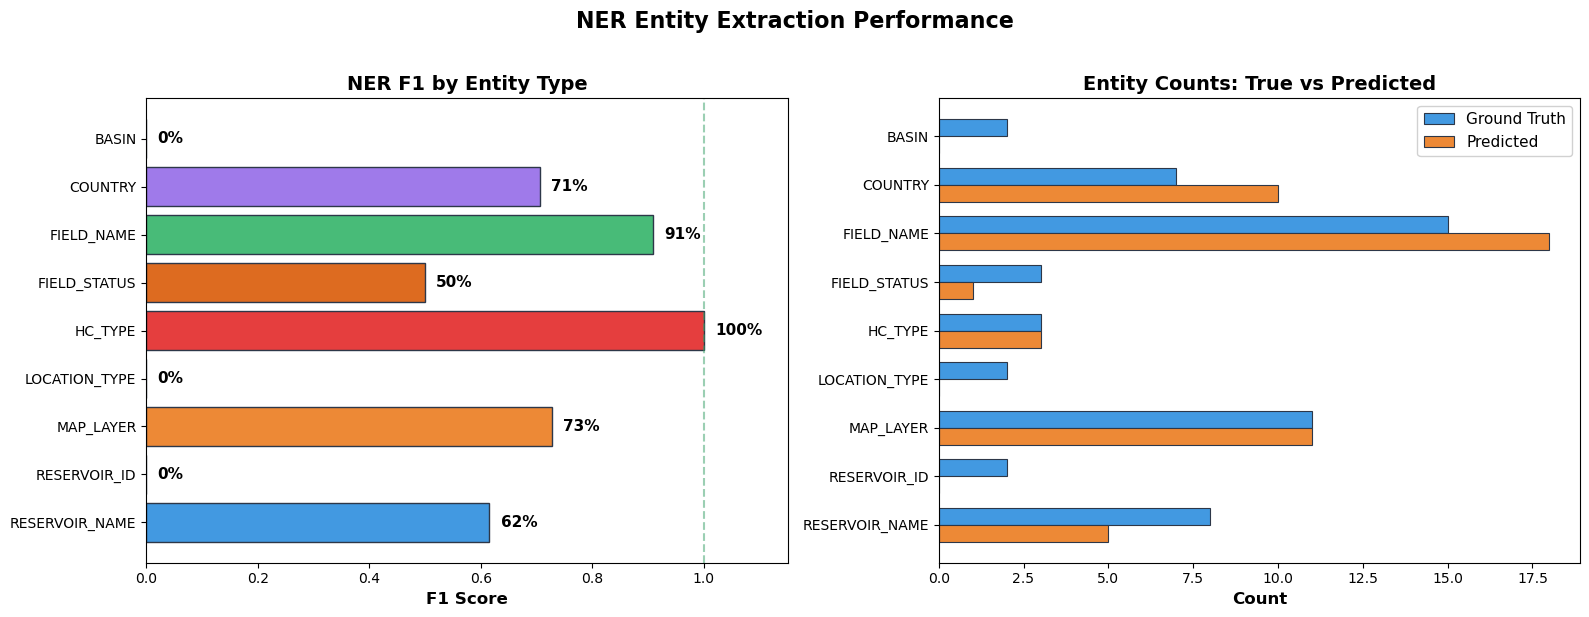

In [10]:
if not perf_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # F1 by entity type
    ent_types = perf_df["Entity"].tolist()
    f1_vals = perf_df["F1"].tolist()
    bar_colors = [NER_COLORS.get(e, "#718096") for e in ent_types]

    bars = axes[0].barh(ent_types, f1_vals, color=bar_colors, edgecolor="#2d3748", linewidth=1)
    axes[0].set_xlim(0, 1.15)
    axes[0].set_xlabel("F1 Score", fontsize=12, fontweight="bold")
    axes[0].set_title("NER F1 by Entity Type", fontsize=14, fontweight="bold")
    for bar, f1 in zip(bars, f1_vals):
        axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f"{f1:.0%}", va="center", fontsize=11, fontweight="bold")
    axes[0].axvline(x=1.0, color="#38a169", linestyle="--", alpha=0.5)
    axes[0].invert_yaxis()

    # True vs Predicted counts
    x = np.arange(len(ent_types))
    w = 0.35
    axes[1].barh(x - w/2, perf_df["True"].tolist(), w, label="Ground Truth",
                color="#4299e1", edgecolor="#2d3748", linewidth=0.8)
    axes[1].barh(x + w/2, perf_df["Predicted"].tolist(), w, label="Predicted",
                color="#ed8936", edgecolor="#2d3748", linewidth=0.8)
    axes[1].set_yticks(x)
    axes[1].set_yticklabels(ent_types)
    axes[1].set_xlabel("Count", fontsize=12, fontweight="bold")
    axes[1].set_title("Entity Counts: True vs Predicted", fontsize=14, fontweight="bold")
    axes[1].legend(fontsize=11, framealpha=0.9)
    axes[1].invert_yaxis()

    fig.suptitle("NER Entity Extraction Performance", fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No entities found in test data.")

## 8. NER Entity Legend

In [11]:
legend_items = []
for etype, color in NER_COLORS.items():
    legend_items.append(
        f'<span style="display:inline-block; background:{color}; color:white; '
        f'padding:4px 12px; border-radius:6px; margin:3px; font-size:12px; '
        f'font-weight:bold;">{etype}</span>'
    )

legend_html = f"""
<div style="background:#f7fafc; padding:12px 16px; border-radius:8px; border:1px solid #e2e8f0; margin:10px 0;">
    <strong style="font-family:system-ui; color:#2d3748;">Entity Color Legend:</strong><br>
    {''.join(legend_items)}
</div>
"""
display(HTML(legend_html))

## 9. Combined Summary Scorecard

In [12]:
intent_acc = res_df["intent_match"].mean()
ner_exact = res_df["ner_match"].mean()
both_correct = (res_df["intent_match"] & res_df["ner_match"]).mean()

def score_color(val):
    if val >= 0.9: return "#48bb78"
    if val >= 0.7: return "#ecc94b"
    return "#fc8181"

scorecard_html = f"""
<div style="display:flex; gap:20px; justify-content:center; margin:20px 0; font-family:system-ui;">
    <div style="background:linear-gradient(135deg, {score_color(intent_acc)}, {score_color(intent_acc)}dd); color:white;
                padding:24px 36px; border-radius:16px; text-align:center; min-width:180px;
                box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
        <div style="font-size:36px; font-weight:bold;">{intent_acc:.0%}</div>
        <div style="font-size:14px; opacity:0.9; margin-top:4px;">Intent Accuracy</div>
    </div>
    <div style="background:linear-gradient(135deg, {score_color(ner_exact)}, {score_color(ner_exact)}dd); color:white;
                padding:24px 36px; border-radius:16px; text-align:center; min-width:180px;
                box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
        <div style="font-size:36px; font-weight:bold;">{ner_exact:.0%}</div>
        <div style="font-size:14px; opacity:0.9; margin-top:4px;">NER Exact Match</div>
    </div>
    <div style="background:linear-gradient(135deg, {score_color(both_correct)}, {score_color(both_correct)}dd); color:white;
                padding:24px 36px; border-radius:16px; text-align:center; min-width:180px;
                box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
        <div style="font-size:36px; font-weight:bold;">{both_correct:.0%}</div>
        <div style="font-size:14px; opacity:0.9; margin-top:4px;">Both Correct</div>
    </div>
</div>
<p style="text-align:center; font-family:system-ui; color:#718096; font-size:12px;">Test set: {len(res_df)} examples (5 per class)</p>
"""
display(HTML(scorecard_html))

## 10. Try Your Own Prompt

Enter any user query below to see the predicted **intent** and **NER entities** with color-coded output.

In [15]:
#USER_PROMPT = "show oil fields in Saudi Arabia"  # Change this to any query

USER_PROMPT = "show fields"  # Change this to any query


tokens = USER_PROMPT.strip().split()
dummy_tags = ["O"] * len(tokens)

pred_intent, pred_ner = predict_single(USER_PROMPT, tokens, dummy_tags)

intent_color = INTENT_COLORS.get(pred_intent, "#718096")

ner_html_parts = []
i = 0
while i < len(tokens):
    tag = pred_ner[i] if i < len(pred_ner) else "O"
    if tag.startswith("B-"):
        etype = tag[2:]
        entity_tokens = [tokens[i]]
        j = i + 1
        while j < len(tokens) and j < len(pred_ner) and pred_ner[j] == f"I-{etype}":
            entity_tokens.append(tokens[j])
            j += 1
        color = NER_COLORS.get(etype, "#718096")
        entity_text = " ".join(entity_tokens)
        ner_html_parts.append(
            f'<span style="background:{color}; color:white; padding:2px 8px; '
            f'border-radius:4px; margin:0 2px; font-weight:bold;">'
            f'{entity_text} <sup style="font-size:9px; opacity:0.85;">{etype}</sup></span>'
        )
        i = j
    else:
        ner_html_parts.append(f'<span style="margin:0 2px;">{tokens[i]}</span>')
        i += 1

tagged_text = " ".join(ner_html_parts)

output_html = f"""
<div style="font-family:system-ui; max-width:700px; margin:16px 0;">
  <div style="background:#f7fafc; border:1px solid #e2e8f0; border-radius:12px; padding:20px; margin-bottom:12px;">
    <div style="font-size:13px; color:#718096; margin-bottom:4px; font-weight:600;">INPUT</div>
    <div style="font-size:18px; color:#2d3748; font-style:italic;">"{USER_PROMPT}"</div>
  </div>
  <div style="display:flex; gap:12px; margin-bottom:16px;">
    <div style="background:{intent_color}; color:white; padding:12px 24px;
                border-radius:10px; font-weight:bold; font-size:15px;
                box-shadow:0 2px 8px {intent_color}66;">
      Intent: {pred_intent}
    </div>
  </div>
  <div style="background:#ffffff; border:1px solid #e2e8f0; border-radius:12px;
              padding:16px 20px; line-height:2.2; font-size:16px;">
    <div style="font-size:13px; color:#718096; margin-bottom:8px; font-weight:600;">NER ENTITIES</div>
    {tagged_text}
  </div>
</div>
"""
display(HTML(output_html))